# Activation Foil Analysis: FLiBe 1L BABY Run #1

This notebook processes the calibration data from HPGe detectors to energy calibrate the detectors and determine total detector efficiencies. Then, NaI measurements of activation foils irradiated during the run with a D-T neutron (14.1 MeV) generator are used to determine the average neutron rate during the run. 

## Obtaining the Data
First, the NaI detector measurement data is obtained from Zenodo and extracted

In [ ]:
# parameters

## keep this if statement for ci and process workflows
if 'download_from_raw' not in globals() and 'download_from_raw' not in locals():
    download_from_raw = False

In [2]:
import numpy as np
from datetime import datetime
import json
from libra_toolbox.neutron_detection.activation_foils import compass
from matplotlib import pyplot as plt

In [3]:
from process_foil_data import get_data

detector_type = "HPGe"
check_source_measurements, background_meas, foil_measurements = get_data(download_from_raw=download_from_raw,
                                                                         h5_filename="activation_data.h5",
                                                                         detector_type=detector_type)

Available detector types:  ['HPGe']
Read in properties of Zr Packet #3 foil
Read in properties of Nb Packet #1 foil
Read in properties of Zr Packet #4 foil
Read in properties of Nb Packet #2 foil
Directory already exists: ../../data/neutron_detection/activation_foils/250804_1L_BABY_Run12/DAQ
Processing Ba133 Count 1...
Found settings.xml file. Using energy bins from file: 4096
Processing Ba133 Count 2...
Found settings.xml file. Using energy bins from file: 4096
Processing Co60 Count 1...
Found settings.xml file. Using energy bins from file: 4096
Processing Co60 Count 2...
Found settings.xml file. Using energy bins from file: 4096
Processing Cs137 Count 1...
Found settings.xml file. Using energy bins from file: 4096
Processing Cs137 Count 2...
Found settings.xml file. Using energy bins from file: 4096
Processing Na22 Count 1...
Found settings.xml file. Using energy bins from file: 4096
Processing Na22 Count 2...
Found settings.xml file. Using energy bins from file: 4096
Processing back

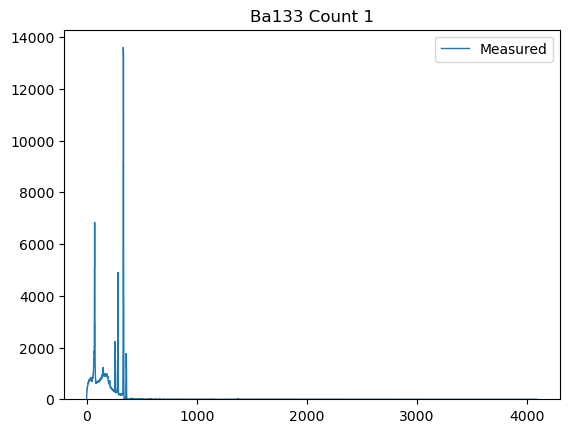

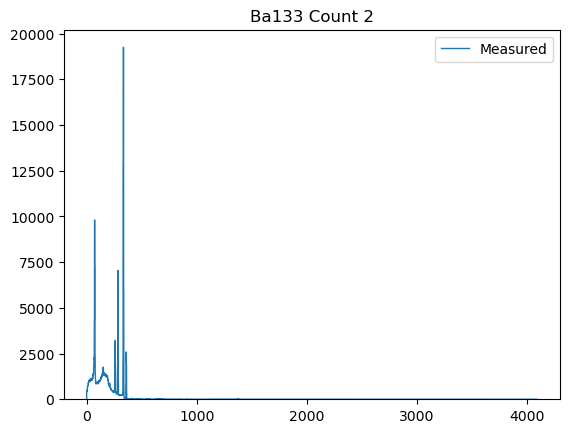

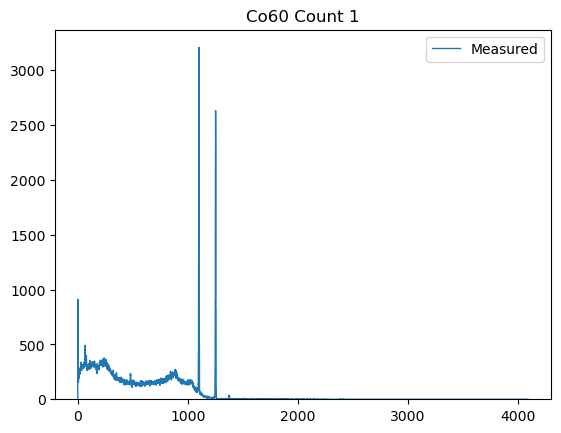

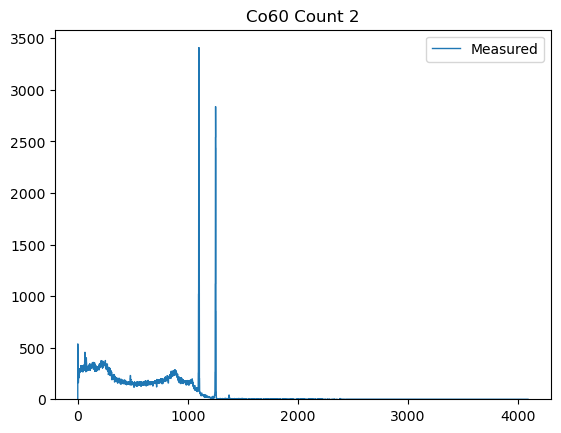

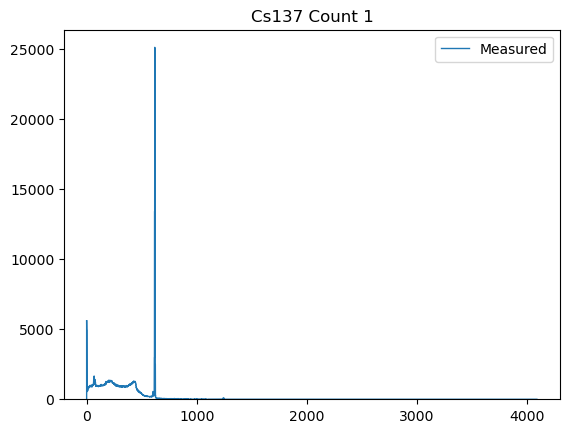

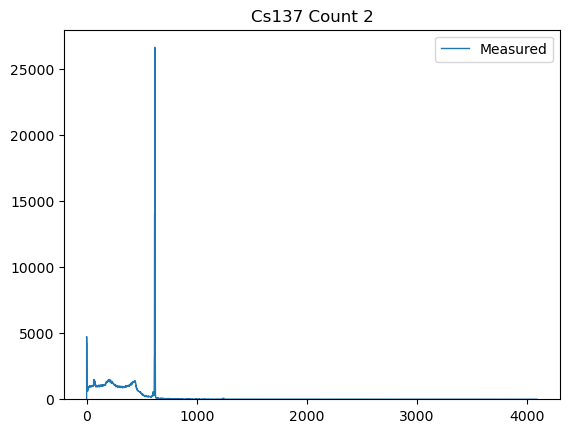

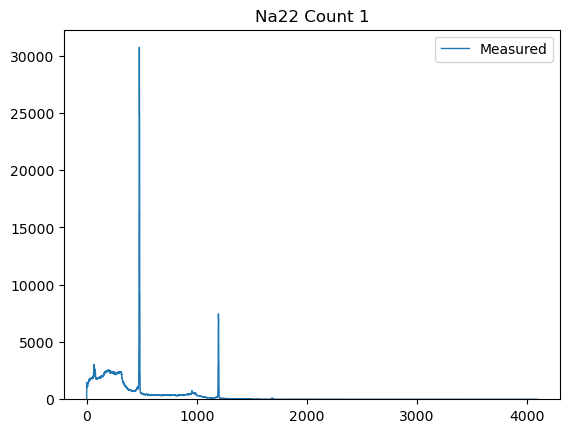

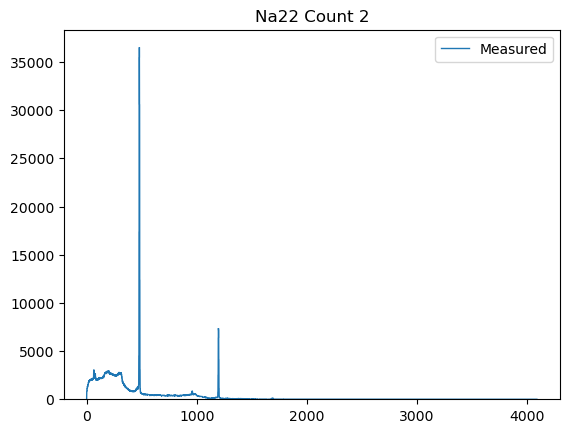

In [4]:
for name, measurement in check_source_measurements.items():
    fig, ax = plt.subplots()
    det = measurement.get_detector(0)
    hist, xvals = det.get_energy_hist()
    ax.stairs(hist, xvals, label=f'Measured')
    ax.legend()
    ax.set_title(name)
    

## Energy Calibration

Using gamma check sources like Co-60 and Cs-137, the characteristic photon peaks from these sources are used to convert the digitizer channel bins into energy (keV) bins

{'Ba133 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8a267380>, 'Ba133 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8a2ade50>, 'Co60 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8a2ae490>, 'Co60 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8a292d70>, 'Cs137 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8a293360>, 'Cs137 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8a025fd0>, 'Na22 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8f5d3020>, 'Na22 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x7f4a8a02de10>}
kwa

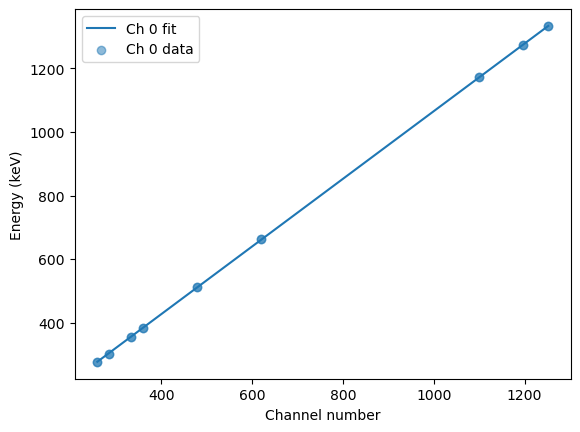

In [5]:
calibration_coeffs = {}
print(check_source_measurements)
channel_nb = check_source_measurements["Ba133 Count 1"].detectors[0].channel_nb

na22_hist, bins = check_source_measurements["Na22 Count 2"].detectors[0].get_energy_hist()

peak_kwargs = {'Na22': {'start_index': 100,
                        'relative_prominence': 0.1,
                        'width': [1, 50],
                        'relative_height': 0.1}}

calibration_channels, calibration_energies = compass.get_calibration_data(
    check_source_measurements.values(),
    background_measurement=background_meas,
    channel_nb=channel_nb,
    peak_kwargs=peak_kwargs,
)

coeff = np.polyfit(calibration_channels, calibration_energies, 1)
calibration_coeffs[channel_nb] = coeff

xs = np.linspace(
    calibration_channels[0],
    calibration_channels[-1],
)
plt.plot(
    xs,
    np.polyval(coeff, xs),
    label=f"Ch {channel_nb} fit",
)
plt.scatter(
    calibration_channels,
    calibration_energies,
    label=f"Ch {channel_nb} data",
    alpha=0.5,
)
plt.xlabel("Channel number")
plt.ylabel("Energy (keV)")
plt.legend()
plt.show()

## Detector Efficiency

Using these same check-sources, each with a known activity, an efficiency curve for each detector is calculated. 

Two types of efficiency curves are shown: 
1. Exponent of sum of logarithms (used in https://doi.org/10.2172/1524045): $ y = \exp(\sum_{i=0}^n a_n \log(E)^i) $

2. Polynomial fit (3rd order): $ y = \sum_{i=0}^n a_n E^i $

**Only the polynomal fit is currently implemented in libra-toolbox, so that is the curve that will be used to calculate the efficiency of the detectors at measuring the activity of the activation foil peaks.**

In [6]:
for name, measurement in check_source_measurements.items():
    for detector in measurement.detectors:
        dead_time_fraction = 1 - detector.live_count_time / detector.real_count_time
        print(f"{name} Ch {detector.channel_nb} \n\t Live time: {detector.live_count_time} s \n\t Real time: {detector.real_count_time} s")
        print(f"\t Dead time fraction: {dead_time_fraction:.2%}")

Ba133 Count 1 Ch 0 
	 Live time: 942.7 s 
	 Real time: 943.404 s
	 Dead time fraction: 0.07%
Ba133 Count 2 Ch 0 
	 Live time: 1230.916 s 
	 Real time: 1231.98 s
	 Dead time fraction: 0.09%
Co60 Count 1 Ch 0 
	 Live time: 1198.833 s 
	 Real time: 1200.107 s
	 Dead time fraction: 0.11%
Co60 Count 2 Ch 0 
	 Live time: 1198.652 s 
	 Real time: 1200.12 s
	 Dead time fraction: 0.12%
Cs137 Count 1 Ch 0 
	 Live time: 146.103 s 
	 Real time: 150.113 s
	 Dead time fraction: 2.67%
Cs137 Count 2 Ch 0 
	 Live time: 146.018 s 
	 Real time: 150.112 s
	 Dead time fraction: 2.73%
Na22 Count 1 Ch 0 
	 Live time: 140.467 s 
	 Real time: 150.13 s
	 Dead time fraction: 6.44%
Na22 Count 2 Ch 0 
	 Live time: 138.99 s 
	 Real time: 150.112 s
	 Dead time fraction: 7.41%


In [7]:
def eff_curve_func(E, *a):
    exponent_term = 0
    for i,a_n in enumerate(a):
        exponent_term += a_n * (np.log(E) ** i)
    return np.exp(exponent_term)

/tmp/ipykernel_3126/695408961.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()










Ch 0 
	 Energies: [ 276.3989  276.3989  302.8508  302.8508  356.0129  356.0129  383.8485
  383.8485  511.      511.      661.657   661.657  1173.228  1173.228
 1274.537  1274.537  1332.492  1332.492 ], 
	 Efficiencies: [0.00746642 0.00833583 0.00736928 0.00678159 0.00633323 0.00579846
 0.00539519 0.00585877 0.00311219 0.00370148 0.0031723  0.00294745
 0.002025   0.00185887 0.00142754 0.00140324 0.00162724 0.00177161]
[-64.46469624  31.35838759  -5.31599694   0.28897032]


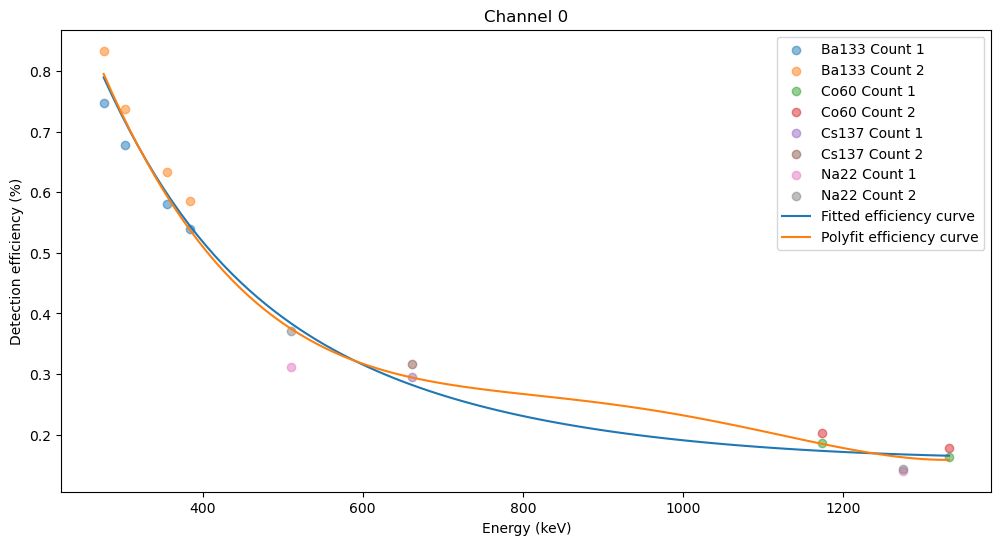

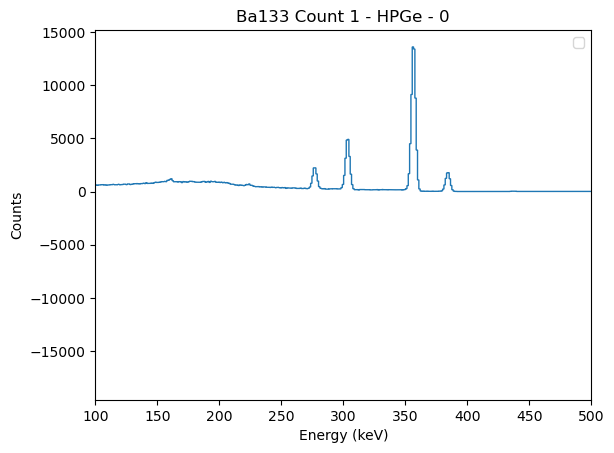

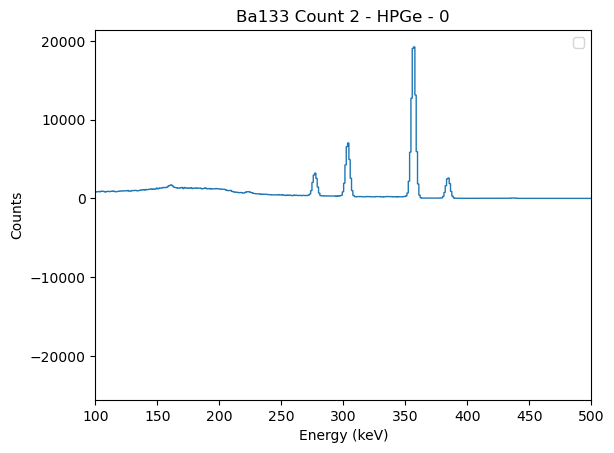

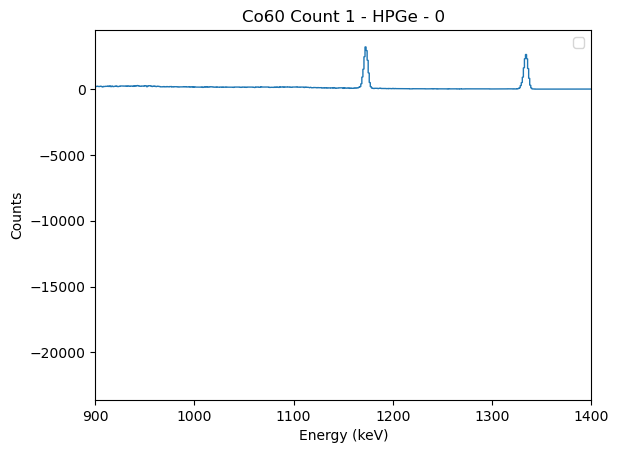

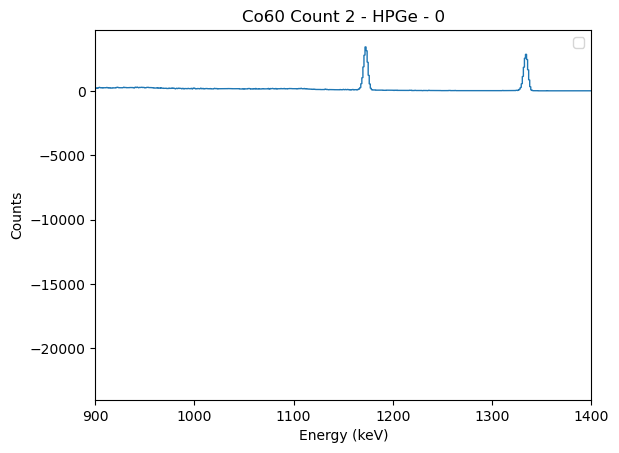

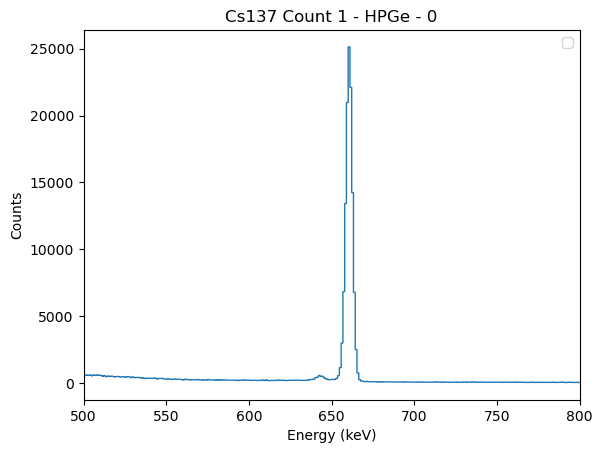

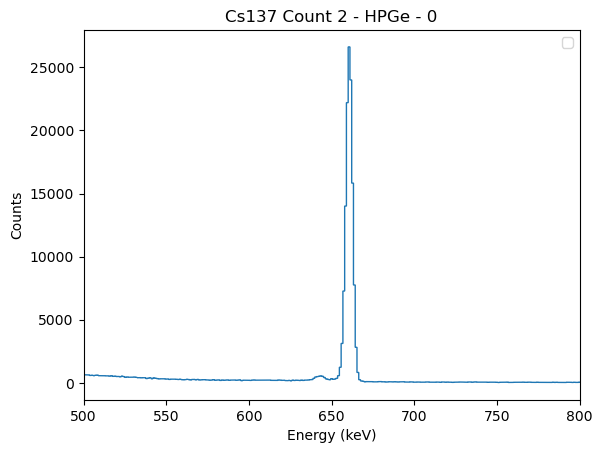

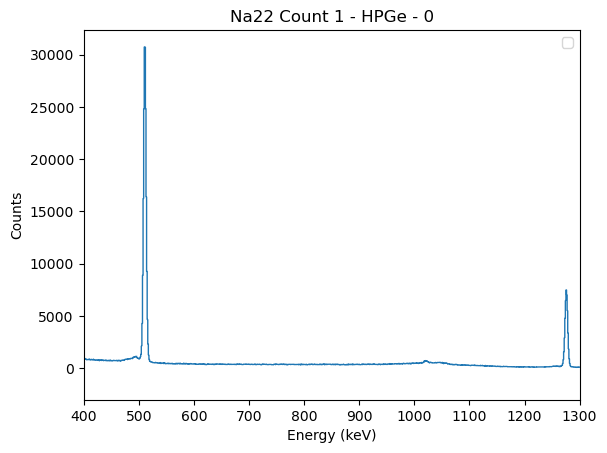

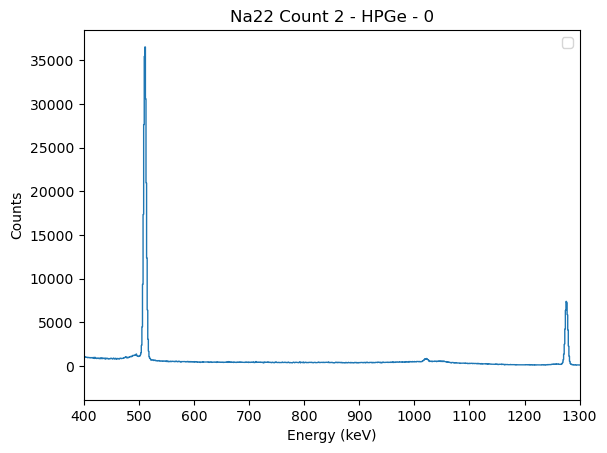

In [8]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

channels = []
efficiency_coeffs = {}
measurement = list(check_source_measurements.values())[0]

# search_widths = np.arange(20, 50, 2)
# for search_width in search_widths:
search_width = 20
threshold_overlap = 10
for detector in measurement.detectors:
    channels.append(detector.channel_nb)

xlim_dict = {
    'Ba133': [100, 500],
    'Co60': [900, 1400],
    'Cs137': [500, 800],
    'Mn54': [600, 900],
    'Na22': [400, 1300],
}

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))

background_detector = background_meas.get_detector(channel_nb)
energies = []
efficiencies = []
for name, measurement in check_source_measurements.items():
    check_source_detector = measurement.get_detector(channel_nb)
    hist, bin_edges = check_source_detector.get_energy_hist_background_substract(background_detector, bins=None)
    calibrated_bin_edges = np.polyval(calibration_coeffs[channel_nb], bin_edges)

    # plot the histogram
    fig2,ax2 = plt.subplots()
    ax2.stairs(hist, calibrated_bin_edges)
    # ax2.set_xlim(left=0, right=500)

    # See how well calibrated peaks match expected energies
    expected_energies = measurement.check_source.nuclide.energy
    for energy in expected_energies:
        lower_ind = np.argmin(np.abs((energy - search_width) - calibrated_bin_edges))
        upper_ind = np.argmin(np.abs((energy + search_width) - calibrated_bin_edges))
        hist_search = hist[lower_ind:upper_ind]

        peaks, peak_params = find_peaks(hist_search, height=np.max(hist_search) * 0.5)

    # print('notebook search_width:', search_width, ' threshold_overlap:', threshold_overlap)

    # uncalibrated = np.array(
    #             measurement.check_source.nuclide._uncalibrated_measured_energies.get(channel_nb, []),
    #             dtype=float
    #         )
    # calibrated_ergs = np.polyval(calibration_coeffs[channel_nb], uncalibrated)


    ax2.set_xlabel("Energy (keV)")
    ax2.set_ylabel("Counts")
    ax2.set_title(f"{measurement.name} - {measurement.detector_type} - {channel_nb}")
    ax2.legend()
    nuclide = name.split()[0]
    if nuclide in xlim_dict:
        ax2.set_xlim(left=xlim_dict[nuclide][0], right=xlim_dict[nuclide][1])
    else:
        ax2.set_xlim(left=0, right=1500)
    
    efficiency = measurement.compute_detection_efficiency(
        background_measurement=background_meas,
        calibration_coeffs=calibration_coeffs[channel_nb],
        channel_nb=channel_nb,
        search_width=search_width,
        threshold_overlap=threshold_overlap,
        # summing_method='sum_gaussian',
        summing_method='sum_histogram'
    )
    print("\n" + "=" * 40)

    energies += measurement.check_source.nuclide.energy
    efficiencies += list(efficiency)
    ax.scatter(
        measurement.check_source.nuclide.energy,
        efficiency * 100,
        label=name,
        alpha=0.5
    )

# Sort energies and efficiencies for fitting
sorted_indices = np.argsort(energies)
energies = np.array(energies)[sorted_indices]
efficiencies = np.array(efficiencies)[sorted_indices]
print(f"Ch {channel_nb} \n\t Energies: {energies}, \n\t Efficiencies: {efficiencies}")

# Fit the efficiency curve
popt, pcov = curve_fit(
    eff_curve_func,
    energies,
    efficiencies,
    p0=[-1, 1, 0, 0],
)

poly_coeff = np.polyfit(energies, efficiencies, 4)
efficiency_coeffs[channel_nb] = poly_coeff
xs = np.linspace(
    energies[0],
    energies[-1],
    100,
)
ax.plot(
    xs,
    eff_curve_func(xs, *popt) * 100,
    label="Fitted efficiency curve",
)

ax.plot(
    xs,
    np.polyval(poly_coeff, xs) * 100,
    label="Polyfit efficiency curve",
)
ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Detection efficiency (%)")
ax.set_title(f"Channel {channel_nb}")
ax.legend()
# plt.ylim(bottom=0)
print(popt)
plt.show()

## Calculating average neutron rate from activation foils

First, the irradiation schedule and the foil information is collected.

In [19]:
from process_foil_data import irradiations
all_neutron_rates = []
all_neutron_rates_err = []

## Irradiation Time

### Zirconium Packet #3 Results

The activity of Zr-89 is measured using its 909 keV gamma peak and used to determine the neutron rate during the irradiation. Zr-89 is formed from the Zr-90(n,2n) reaction, which has a threshold energy of ~12 MeV. 

The gamma spectrum obtained from the various measurements of the Zirconium Packet #3 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [20]:
print(foil_measurements["Zr Packet #3"])

{'measurement_paths': {1: PosixPath('../../data/neutron_detection/activation_foils/250804_1L_BABY_Run12/DAQ/Zirconium3_20250804_1650_count1/UNFILTERED')}, 'foil': ActivationFoil(reaction=Reaction(reactant=Nuclide(name='Zr90', energy=None, intensity=None, half_life=None, atomic_mass=89.90469876, abundance=0.515), product=Nuclide(name='Zr89', energy=[909.15], intensity=[0.9904], half_life=282276.0, atomic_mass=None, abundance=1.0), cross_section=6.2389e-25, type='(n,2n)'), mass=0.4498, name='Zr Packet #3', density=6.505, thickness=0.050800000000000005), 'distance_to_source': 6, 'measurements': {1: <libra_toolbox.neutron_detection.activation_foils.compass.SampleMeasurement object at 0x7f4a8a267770>}}


In [21]:
from process_foil_data import calculate_neutron_rate_from_foil

foil_name = "Zr Packet #3"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=search_width,
                                                                    irradiations=irradiations)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])


Count 1
	 Ch 0: Neutron rate: 1.673e+09 +/- 1.485e+07 n/s


### Zirconium Packet #4 Results

The activity of Zr-89 is measured using its 909 keV gamma peak and used to determine the neutron rate during the irradiation. Zr-89 is formed from the Zr-90(n,2n) reaction, which has a threshold energy of 12.1 MeV. 

The gamma spectrum obtained from the various measurements of the Zirconium Packet #1 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [22]:
foil_name = "Zr Packet #4"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=search_width,
                                                                    irradiations=irradiations)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])

Count 1
	 Ch 0: Neutron rate: 1.834e+09 +/- 1.768e+07 n/s


In [23]:
foil_name = "Nb Packet #1"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=search_width,
                                                                    irradiations=irradiations)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])

Count 1
	 Ch 0: Neutron rate: 2.020e+09 +/- 2.110e+07 n/s
Count 2
	 Ch 0: Neutron rate: 1.062e+09 +/- 1.349e+07 n/s


In [27]:
# These results seem off, as with recorded mass, the rate seems to be pretty much exactly double of what I'd expect

# foil_name = "Nb Packet #2"

# neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
#                                                                     foil_name,
#                                                                     background_meas,
#                                                                     calibration_coeffs,
#                                                                     efficiency_coeffs,
#                                                                     search_width=search_width,
#                                                                     irradiations=irradiations)

# for count_name in neutron_rates.keys():
#     print(count_name)
#     for ch in np.sort(list(neutron_rates[count_name].keys())):
#         neutron_rate = neutron_rates[count_name][ch]
#         neutron_rate_err = neutron_rate_errs[count_name][ch]
#         print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
#         all_neutron_rates.append(neutron_rate[0])
#         all_neutron_rates_err.append(neutron_rate_err[0])

### Averaging foil results

The average of the neutron rates of the Niobium and Zirconium foil packets is calculated and added to the processed_data.json file. 

In [28]:
# remove outliers using z-score method
from scipy import stats
z_scores = np.abs(stats.zscore(all_neutron_rates))
threshold = 1.5  # Set your desired threshold for z-score
filtered_indices = np.where(z_scores < threshold)[0]
all_neutron_rates = np.array(all_neutron_rates)[filtered_indices]

average_neutron_rate = np.mean(all_neutron_rates)
# average_neutron_rate_err = np.sqrt(np.sum(np.array(all_neutron_rates_err) ** 2)) / len(all_neutron_rates_err)
average_neutron_rate_err = np.std(all_neutron_rates, ddof=1)  # Use ddof=1 for sample standard deviation

print(f"Average neutron rate: {average_neutron_rate:.3e} ± {average_neutron_rate_err:.3e} n/s")


Average neutron rate: 1.842e+09 ± 1.737e+08 n/s


In [26]:
processed_data_file = "../../data/processed_data.json"

processed_data = {
    "neutron_rate_used_in_model": {
        "value":average_neutron_rate,
        "error": average_neutron_rate_err,
        "unit": "neutron / second"
    }
}

try:
    with open(processed_data_file, "r") as f:
        existing_data = json.load(f)
except FileNotFoundError:
    print(f"Processed data file not found, creating it in {processed_data_file}")
    existing_data = {}

existing_data.update(processed_data)

with open(processed_data_file, "w") as f:
    json.dump(existing_data, f, indent=4)

print(f"Processed data stored in {processed_data_file}")

Processed data stored in ../../data/processed_data.json
